In [1]:
%load_ext memory_profiler
import pandas as pd
import numpy as np
import scipy
import scanpy as sc
import os
import anndata
import LingerGRN.LINGER_tr as LINGER_tr
import LingerGRN.LL_net as LL_net
from LingerGRN.preprocess import *
from LingerGRN.pseudo_bulk import *
from LingerGRN.TF_activity import *
from LingerGRN import Compare

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [2]:
method='LINGER'
Datadir='/home/qyyuan/data/TF_TG_software/code/'# This directory should be the same as Datadir defined in the above 'Download the general gene regulatory network' section
GRNdir=Datadir+'data_bulk/'
genome='hg38'
method ='LINGER'
outdir='/home/qyyuan/project/Nature-Protocol/PBMC-p-results/' #output dir
if not os.path.exists(outdir):
    os.makedirs(outdir)
%memit

peak memory: 420.03 MiB, increment: 0.00 MiB


In [ ]:
rna_path = '/home/qyyuan/data/CECI/PBMC/RNA.txt'
atac_path = '/home/qyyuan/data/CECI/PBMC/ATAC.txt'
label_path = '/home/qyyuan/project/Nature-Protocol/PBMC/label.txt'
RNA = pd.read_csv(rna_path, sep='\t', header=0, index_col=0)
ATAC = pd.read_csv(atac_path, sep='\t', header=0, index_col=0)
label = pd.read_csv(label_path, sep='\t', header=0, index_col=None)
matrix = csc_matrix(pd.concat([RNA,ATAC],axis=0).values)
features=pd.DataFrame(RNA.index.tolist()+ATAC.index.tolist(),columns=[1])
K=RNA.shape[0]
N=K+ATAC.shape[0]
types = ['Gene Expression' if i <= K else 'Peaks' for i in range(0, N)]
features[2]=types
barcodes=pd.DataFrame(RNA.columns.values,columns=[0])
adata_RNA,adata_ATAC=get_adata(matrix,features,barcodes,label)# adata_RNA and adata_ATAC are scRNA and scATAC
%memit

In [ ]:
sc.pp.filter_cells(adata_RNA, min_genes=200)
sc.pp.filter_genes(adata_RNA, min_cells=3)
sc.pp.filter_cells(adata_ATAC, min_genes=200)
sc.pp.filter_genes(adata_ATAC, min_cells=3)
selected_barcode=list(set(adata_RNA.obs['barcode'].values)&set(adata_ATAC.obs['barcode'].values))
barcode_idx=pd.DataFrame(range(adata_RNA.shape[0]), index=adata_RNA.obs['barcode'].values)
adata_RNA = adata_RNA[barcode_idx.loc[selected_barcode][0]]
barcode_idx=pd.DataFrame(range(adata_ATAC.shape[0]), index=adata_ATAC.obs['barcode'].values)
adata_ATAC = adata_ATAC[barcode_idx.loc[selected_barcode][0]]
%memit

Trying to modify attribute `.obs` of view, initializing view as actual.
Trying to modify attribute `.obs` of view, initializing view as actual.


peak memory: 23934.63 MiB, increment: 0.00 MiB


In [ ]:

samplelist=list(set(adata_ATAC.obs['sample'].values)) # sample is generated from cell barcode 
tempsample=samplelist[0]
TG_pseudobulk=pd.DataFrame([])
RE_pseudobulk=pd.DataFrame([])
singlepseudobulk = (adata_RNA.obs['sample'].unique().shape[0]*adata_RNA.obs['sample'].unique().shape[0]>100)
for tempsample in samplelist:
    adata_RNAtemp=adata_RNA[adata_RNA.obs['sample']==tempsample]
    adata_ATACtemp=adata_ATAC[adata_ATAC.obs['sample']==tempsample]
    TG_pseudobulk_temp,RE_pseudobulk_temp=pseudo_bulk(adata_RNAtemp,adata_ATACtemp,singlepseudobulk)                
    TG_pseudobulk=pd.concat([TG_pseudobulk, TG_pseudobulk_temp], axis=1)
    RE_pseudobulk=pd.concat([RE_pseudobulk, RE_pseudobulk_temp], axis=1)
    RE_pseudobulk[RE_pseudobulk > 100] = 100
%memit


Received a view of an AnnData. Making a copy.
Received a view of an AnnData. Making a copy.
Received a view of an AnnData. Making a copy.
Received a view of an AnnData. Making a copy.


peak memory: 23951.75 MiB, increment: 0.00 MiB


In [ ]:
import os
if not os.path.exists('data/'):
    os.mkdir('data/')
adata_ATAC.write('data/adata_ATAC.h5ad')
adata_RNA.write('data/adata_RNA.h5ad')
TG_pseudobulk=TG_pseudobulk.fillna(0)
RE_pseudobulk=RE_pseudobulk.fillna(0)
pd.DataFrame(adata_ATAC.var['gene_ids']).to_csv('data/Peaks.txt',header=None,index=None)
TG_pseudobulk.to_csv('data/TG_pseudobulk.tsv')
RE_pseudobulk.to_csv('data/RE_pseudobulk.tsv')
%memit

Trying to modify attribute `.obs` of view, initializing view as actual.
Trying to modify attribute `.obs` of view, initializing view as actual.
Trying to modify attribute `.obs` of view, initializing view as actual.
Trying to modify attribute `.obs` of view, initializing view as actual.


peak memory: 23952.75 MiB, increment: 0.00 MiB


In [ ]:
preprocess(TG_pseudobulk,RE_pseudobulk,GRNdir,genome,method,outdir)
%memit        


Overlapping regions...


[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    6.3s
[Parallel(n_jobs=8)]: Done  11 out of  23 | elapsed:    8.4s remaining:    9.2s
[Parallel(n_jobs=8)]: Done  14 out of  23 | elapsed:    8.9s remaining:    5.7s
[Parallel(n_jobs=8)]: Done  17 out of  23 | elapsed:    9.2s remaining:    3.3s
[Parallel(n_jobs=8)]: Done  20 out of  23 | elapsed:   10.0s remaining:    1.5s
[Parallel(n_jobs=8)]: Done  23 out of  23 | elapsed:   11.1s finished


Mapping gene expression...
Generate TF expression...
Generate RE chromatin accessibility...
Generate TF binding...


[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    6.4s
A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak

Generate Index...


100%|██████████| 14907/14907 [00:57<00:00, 258.24it/s]


peak memory: 20308.58 MiB, increment: 0.00 MiB


In [ ]:
activef='ReLU' # active function chose from 'ReLU','sigmoid','tanh'
LINGER_tr.training(GRNdir,method,outdir,activef,'Human')
%memit 

With 128 CPUs, 1007.71 GB RAM (avail. : 997.28 GB), start 23 workers


[Parallel(n_jobs=23)]: Using backend LokyBackend with 23 concurrent workers.
chr1: 100%|██████████| 1520/1520 [40:29<00:00,  1.60s/it]
[Parallel(n_jobs=23)]: Done  23 out of  23 | elapsed: 41.3min finished


peak memory: 791.15 MiB, increment: 0.00 MiB


In [39]:
adata_ATAC=sc.read('data/adata_ATAC.h5ad')
adata_RNA=sc.read('data/adata_RNA.h5ad')

In [ ]:
LL_net.TF_RE_binding(GRNdir,adata_RNA,adata_ATAC,genome,method,outdir)
LL_net.cis_reg(GRNdir,adata_RNA,adata_ATAC,genome,method,outdir)
LL_net.trans_reg(GRNdir,method,outdir,genome)

Generating cellular population TF binding strength ...


[Parallel(n_jobs=23)]: Using backend LokyBackend with 23 concurrent workers.
chr19: 100%|██████████| 22/22 [07:18<00:00, 19.94s/it]
[Parallel(n_jobs=23)]: Done  23 out of  23 | elapsed:  7.6min finished
chr1: 100%|██████████| 1520/1520 [00:02<00:00, 697.40it/s] 


Generate trans-regulatory netowrk ...


chr1: 100%|██████████| 1520/1520 [00:01<00:00, 875.45it/s]


Save trans-regulatory netowrk ...


In [4]:
celltype='naive B cells' #use a string to assign your cell type
LL_net.cell_type_specific_TF_RE_binding(GRNdir,adata_RNA,adata_ATAC,genome,celltype,outdir,method)# different from the previous version
LL_net.cell_type_specific_cis_reg(GRNdir,adata_RNA,adata_ATAC,genome,celltype,outdir,method)
LL_net.cell_type_specific_trans_reg(GRNdir,adata_RNA,celltype,outdir)

Generate cell type specitic TF binding potential for cell type naive B cells...


[Parallel(n_jobs=23)]: Using backend LokyBackend with 23 concurrent workers.
[Parallel(n_jobs=23)]: Done   2 out of  23 | elapsed:    9.7s remaining:  1.7min
[Parallel(n_jobs=23)]: Done   5 out of  23 | elapsed:   12.3s remaining:   44.4s
[Parallel(n_jobs=23)]: Done   8 out of  23 | elapsed:   16.0s remaining:   29.9s
[Parallel(n_jobs=23)]: Done  11 out of  23 | elapsed:   18.2s remaining:   19.8s
[Parallel(n_jobs=23)]: Done  14 out of  23 | elapsed:   20.4s remaining:   13.1s
[Parallel(n_jobs=23)]: Done  17 out of  23 | elapsed:   23.5s remaining:    8.3s
[Parallel(n_jobs=23)]: Done  20 out of  23 | elapsed:   28.4s remaining:    4.3s
[Parallel(n_jobs=23)]: Done  23 out of  23 | elapsed:   40.1s finished
100%|██████████| 23/23 [02:40<00:00,  6.98s/it]


Clustering large matrix with scipy. Installing `fastcluster` may give better performance.


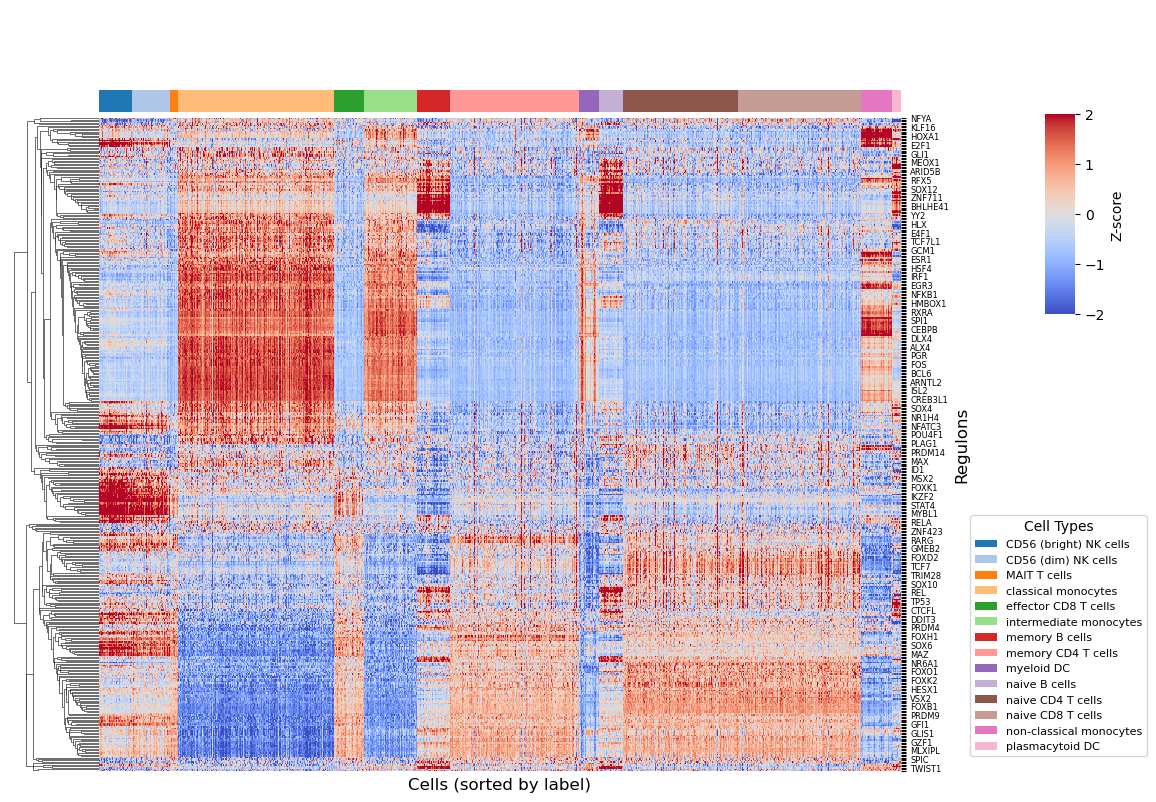

peak memory: 1710.78 MiB, increment: 0.00 MiB


In [5]:
from LingerGRN.TF_activity import *
network='cell population'
TF_activity=regulon(outdir,adata_RNA,GRNdir,network,genome)
save=False
heatmap_cluster(TF_activity,adata_RNA,save,outdir)
%memit

In [6]:
celltype='naive B cells'
t_test_results=master_regulator(TF_activity,adata_RNA,celltype)
t_test_results



Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.


,t_stat,p_value,adj_p
AHR,-11.342573,1.000000e+00,1.000000e+00
AIRE,1.829671,3.366515e-02,8.626694e-02
ALX3,4.714534,1.228483e-06,3.985943e-06
ALX4,-6.480649,1.000000e+00,1.000000e+00
AR,22.726023,1.083102e-111,9.968962e-111
...,...,...,...
ZNF423,7.415188,6.590021e-14,2.518728e-13
ZNF691,1.912559,2.791724e-02,7.194672e-02
ZNF711,60.341488,0.000000e+00,0.000000e+00
ZNF740,24.538164,2.719911e-129,2.725955e-128


peak memory: 1710.79 MiB, increment: 0.00 MiB


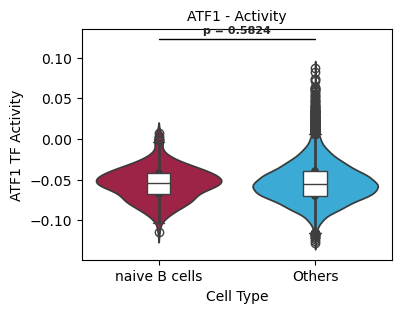

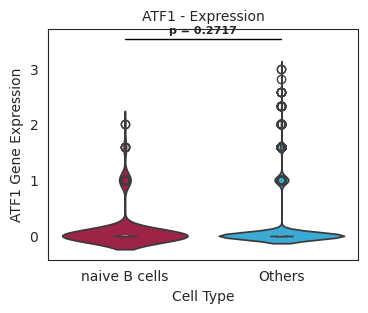

In [7]:
TFName='ATF1'
datatype='activity'
celltype1='naive B cells'
celltype2='Others'
save=True
box_comp(TFName,adata_RNA,celltype1,celltype2,datatype,TF_activity,save,outdir)
datatype='expression'
box_comp(TFName,adata_RNA,celltype1,celltype2,datatype,TF_activity,save,outdir)
%memit

In [13]:
TF_RE = pd.read_csv(outdir + 'cell_type_specific_TF_RE_binding_naive B cells.txt', sep='\t', header=0, index_col=0)
TF_TG=pd.read_csv(outdir + 'cell_type_specific_trans_regulatory_naive B cells.txt',sep='\t',index_col=0,header=0)

In [18]:
!cat "{outdir}cell_type_specific_cis_regulatory_naive B cells.txt" | grep MS4A1 > "{outdir}naiveB_MS4A1_TG.txt"
!cat "{outdir}cell_type_specific_cis_regulatory_naive B cells.txt" | grep GAPDH > "{outdir}naiveB_GAPDH_TG.txt"

In [23]:
MS4A1 = pd.read_csv(outdir+'naiveB_MS4A1_TG.txt',sep='\t',header=None)
GAPDH = pd.read_csv(outdir+'naiveB_GAPDH_TG.txt',sep='\t',header=None)


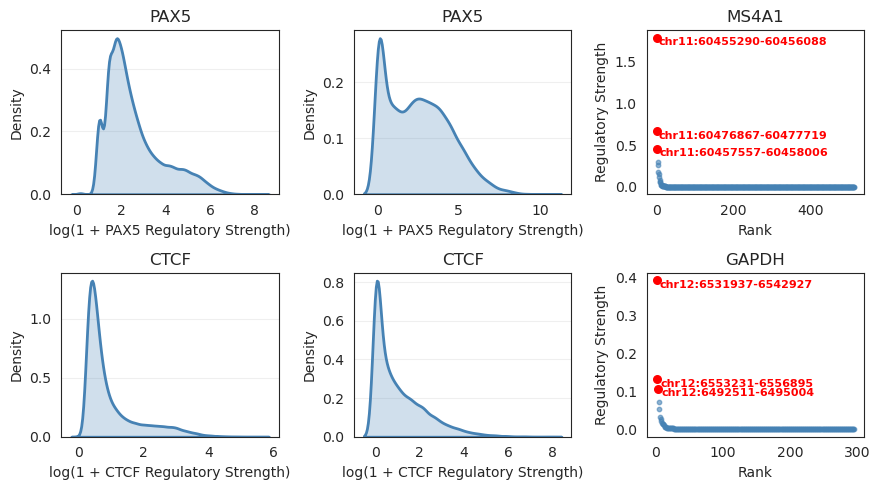

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
configs = [
    (0, 0, 'TF_RE', 'PAX5', 'PAX5 Regulatory Strength'),
    (0, 1, 'TF_TG', 'PAX5', 'PAX5 Regulatory Strength'),
    (1, 0, 'TF_RE', 'CTCF', 'CTCF Regulatory Strength'),
    (1, 1, 'TF_TG', 'CTCF', 'CTCF Regulatory Strength'),
]

fig, axes = plt.subplots(2, 3, figsize=(9, 5))

for row, col, data_type, gene, xlabel in configs:
    ax = axes[row, col]
    data = globals()[data_type][gene]
    sns.kdeplot(np.log(1 + data), fill=True, color='steelblue', linewidth=2, ax=ax)
    ax.set_title(gene, fontsize=12)
    ax.set_xlabel(f'log(1 + {xlabel})', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

ax = axes[0, 2]
df = pd.DataFrame(MS4A1.values, columns=['label', 'other', 'value'])
df_sorted = df.sort_values('value', ascending=False).reset_index(drop=True)
df_sorted['rank'] = range(1, len(df_sorted) + 1)
ax.scatter(df_sorted['rank'], df_sorted['value'], alpha=0.6, s=10, color='steelblue')
top3 = df_sorted.head(3)
for _, row in top3.iterrows():
    ax.annotate(row['label'], xy=(row['rank'], row['value']),
                xytext=(row['rank'] + 5, row['value'] - 0.05 * df_sorted['value'].max()),
                fontsize=8, ha='left', color='red', weight='bold')
ax.scatter(top3['rank'], top3['value'], color='red', s=30, zorder=5)
ax.set_xlabel('Rank', fontsize=10)
ax.set_ylabel('Regulatory Strength', fontsize=10)
ax.set_title('MS4A1', fontsize=12)

ax = axes[1, 2]
df = pd.DataFrame(GAPDH.values, columns=['label', 'other', 'value'])
df_sorted = df.sort_values('value', ascending=False).reset_index(drop=True)
df_sorted['rank'] = range(1, len(df_sorted) + 1)
ax.scatter(df_sorted['rank'], df_sorted['value'], alpha=0.6, s=10, color='steelblue')
top3 = df_sorted.head(3)
for _, row in top3.iterrows():
    ax.annotate(row['label'], xy=(row['rank'], row['value']),
                xytext=(row['rank'] + 5, row['value'] - 0.05 * df_sorted['value'].max()),
                fontsize=8, ha='left', color='red', weight='bold')
ax.scatter(top3['rank'], top3['value'], color='red', s=30, zorder=5)
ax.set_xlabel('Rank', fontsize=10)
ax.set_ylabel('Regulatory Strength', fontsize=10)
ax.set_title('GAPDH', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
features_to_plot = ['PAX5','MYC', 'STAT1',]  # 替换为你的特征名
TF_activity = TF_activity.T
for feature in features_to_plot:
    if feature in TF_activity.columns:
        adata_RNA.obs[feature] = TF_activity.loc[adata_RNA.obs_names, feature].values
    else:
        print(f"Warning: {feature} not in TF_activity")

In [41]:
adata_RNA.obs.columns=['barcode', 'sample', 'label', 'n_genes_by_counts', 'total_counts',
       'total_counts_mt', 'pct_counts_mt', 'n_genes', 'PAX5_activity', 'MYC_activity', 
       'STAT1_activity']

In [ ]:
sc.pp.normalize_total(adata_RNA, target_sum=1e4)
sc.pp.log1p(adata_RNA)
sc.pp.highly_variable_genes(adata_RNA, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata_RNA.raw = adata_RNA
adata_RNA = adata_RNA[:, adata_RNA.var.highly_variable]
sc.pp.scale(adata_RNA, max_value=10)
sc.tl.pca(adata_RNA, svd_solver='arpack')
sc.pp.neighbors(adata_RNA, n_pcs=14, use_rep='X_pca')
sc.tl.umap(adata_RNA)

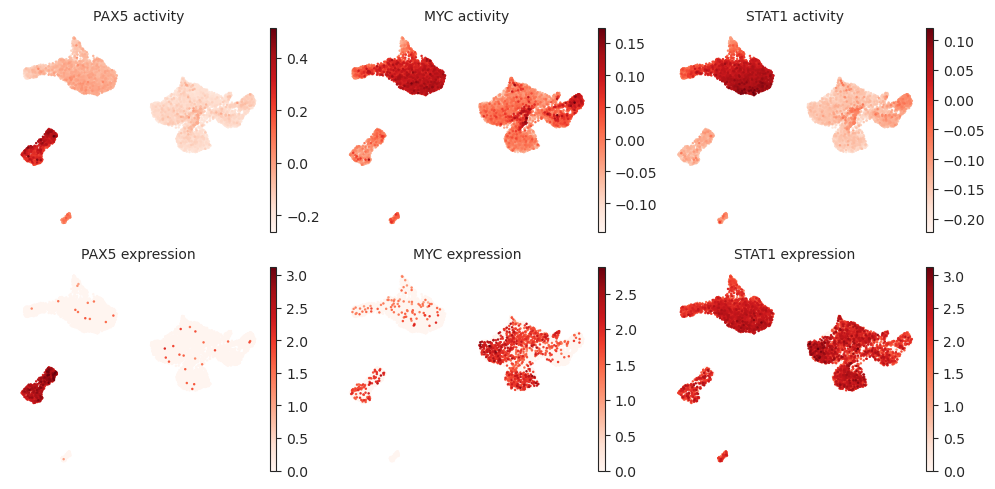

In [43]:

fig, axes = plt.subplots(2, 3, figsize=(10, 5))
colors = ['PAX5_activity', 'MYC_activity', 'STAT1_activity']
for i, c in enumerate(colors):
    sc.pl.umap(
        adata_RNA,
        color=c,
        cmap='Reds',
        use_raw=False,
        ax=axes[0, i],
        show=False,
        frameon=False
    )
    axes[0, i].set_title(c.replace('_', ' '), fontsize=10)
colors2 = ['PAX5_expression', 'MYC_expression', 'STAT1_expression']
for i, c in enumerate(colors2):
    sc.pl.umap(
        adata_RNA,
        color=c.split('_')[0],
        cmap='Reds',
        use_raw=True,
        ax=axes[1, i],
        show=False,
        frameon=False
    )
    axes[1, i].set_title(c.replace('_', ' '), fontsize=10)
axes[0, 0].set_ylabel('TF Activity', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Gene Expression', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('umap_TF_activity_vs_gene_expression.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
from LingerGRN import Compare
import pandas as pd
import numpy as np
outdir='/home/qyyuan/project/Nature-Protocol/PBMC-p-results/'
K=8
Module_result,df_normalized0=Compare.Module_trans(outdir,K,cut_TG=0.85,cut_TF=0.5)

loading GRN......


/home/qyyuan/project/Nature-Protocol/LINGER-main/code/lingergrn-1.106/LingerGRN/Compare.py:113: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_normalized = df_normalized[col_variances > 0]


identify modules......


In [11]:
S_TG = Module_result.S_TG
S_TF = Module_result.S_TF
S_TG['Module'] = S_TG['Module'].astype(int)
S_TF['Module'] = S_TF['Module'].astype(int)

In [12]:
TFlist = []
TFmodule = []
TGlist = []
TGmodule = []

for i in range(K):
    TFtemp = S_TF[S_TF['Module']==(i+1)].index.to_list()
    TFlist = TFlist+TFtemp
    TFmodule =TFmodule+ ['Module_'+str(i+1) for j in range(len(TFtemp))]
    TGtemp = S_TG[S_TG['Module']==(i+1)].index.to_list()
    TGlist = TGlist+TGtemp
    TGmodule = TGmodule + ['Module_'+str(i+1) for j in range(len(TGtemp))]

In [13]:
df_heatmap1= df_normalized0.loc[TFlist][TGlist]
data0=df_heatmap1.values
data0[data0<0]=0
df_heatmap2=pd.DataFrame(np.log(1+data0),index=df_heatmap1.index,columns=df_heatmap1.columns)
df_heatmap2[df_heatmap2>2]=2

/home/qyyuan/project/Nature-Protocol/LINGER-main/code/lingergrn-1.106/LingerGRN/Compare.py:366: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()


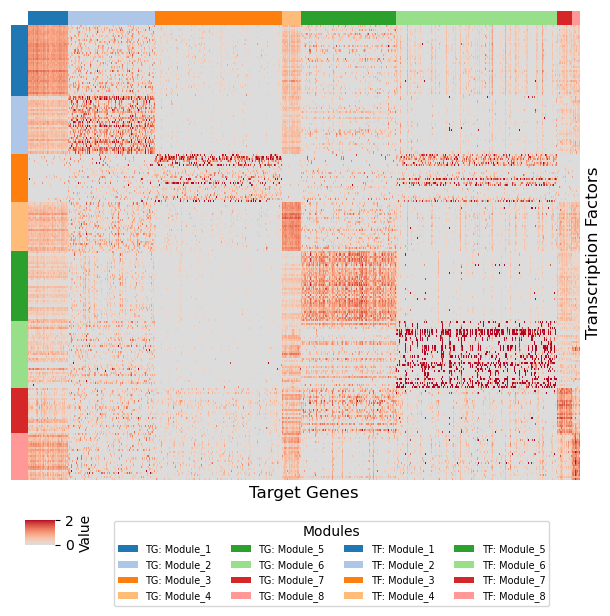

In [15]:

g = Compare.plot_heatmap_with_annotations(
    df_heatmap2, 
    TGmodule, 
    TFmodule,
    save_path=None
)